# Entregavel 2 - Atividade de vendas no Brasil
##  Parte 1 - NumPy

In [ ]:
import numpy as np
import pandas as pd

#Usando pandas pra carregar os dados iniciais
df_raw = pd.read_csv("data/vendas_brasil_1.csv")

#A. Criando arrays
preco_unitario = df_raw['preco_unitario'].to_numpy()
custo_unitario = df_raw['custo_unitario'].to_numpy()
quantidade = df_raw['quantidade'].to_numpy()
desconto_pct = df_raw['desconto_pct'].to_numpy()
receita_total = df_raw['receita_total'].to_numpy()

#B. Calculos com operacoes vetorizadas (sem usar for)
valor_bruto = preco_unitario * quantidade
valor_desconto = valor_bruto * (desconto_pct / 100)
custo_total = custo_unitario * quantidade
lucro_estimado = receita_total - custo_total

#C. Mascaras booleanas
receita_media = np.mean(receita_total)
mascara_receita_acima_media = receita_total > receita_media
mascara_prejuizo = lucro_estimado < 0
mascara_desconto_alto = desconto_pct > 15 #Considerando 15% como desconto alto

#Mostrando quantos casos encontramos
print("Vendas acima da media:", np.sum(mascara_receita_acima_media))
print("Vendas com prejuizo:", np.sum(mascara_prejuizo))
print("Vendas com desconto alto:", np.sum(mascara_desconto_alto))

#D. Agregacoes
print("--- Agregacoes Gerais ---")
print("Receita media: R$", np.mean(receita_total).round(2))
print("Maior receita: R$", np.max(receita_total).round(2))
print("Menor receita: R$", np.min(receita_total).round(2))
print("Lucro medio: R$", np.mean(lucro_estimado).round(2))
print("Quantidade de vendas com prejuizo:", np.sum(mascara_prejuizo))

Vendas acima da média: 9236
Vendas com prejuízo: 2168
Vendas com desconto alto: 11640
--- Agregações Gerais ---
Receita média: R$ 1891.69
Maior receita: R$ 58430.28
Menor receita: R$ 3.7
Lucro médio: R$ 513.19
Quantidade de vendas com prejuízo: 2168


**Conclusao parte 1:**
O uso do NumPy permitiu realizar os calculos financeiros base do dataset de forma rapida e facil. Foi possivel observar que existem vendas que deram prejuizo e algumas vendas com um desconto consideravelmente alto, o que deve impactar o lucro médio geral.

## Entregavel Parte 2 - Pandas

In [ ]:
#Recarregando o dataframe para o modulo de Pandas
df = pd.read_csv("data/vendas_brasil_1.csv")

#A. Primeiro olhar no dataset
print("----Cabecalho do Dataset (head)----")
display(df.head()) 

print("\n----Informacoes das Colunas (info)----")
df.info()

print("\n----Estatisticas Descritivas (describe)----")
display(df.describe())

print("\n----Shape do Dataset (linhas, colunas)----")
print(df.shape)

print("\n----Valores Nulos (isna)----")
print(df.isna().sum())

--- Cabeçalho do Dataset (head) ---


,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False



--- Informações das Colunas (info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  object 
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  object 
 3   canal_venda         37567 non-null  object 
 4   categoria           37617 non-null  object 
 5   produto             37617 non-null  object 
 6   vendedor            37577 non-null  object 
 7   fidelidade_cliente  37617 non-null  object 
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cli

,mes,preco_unitario,custo_unitario,margem_pct,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias
count,37617.000000,37617.000000,37617.000000,37535.000000,37617.000000,37617.000000,37617.000000,35738.000000,34662.000000,36113.000000
mean,6.517691,253.214933,183.620999,22.714776,7.481750,9.494048,1891.688173,29.885737,3.912094,10.017113
std,3.439296,316.742367,231.376757,8.670213,4.322273,9.097484,2972.445759,24.765161,0.932256,5.477487
min,1.000000,4.940000,3.010000,-0.570000,1.000000,0.000000,3.700000,3.750000,1.000000,1.000000
25%,4.000000,68.960000,49.550000,16.380000,4.000000,0.300000,364.280000,12.190000,3.490000,5.000000
50%,7.000000,111.300000,80.990000,22.700000,7.000000,9.000000,789.570000,22.250000,4.010000,10.000000
75%,9.000000,257.680000,186.570000,29.250000,11.000000,19.000000,1853.210000,39.480000,4.520000,15.000000
max,12.000000,9008.600000,6578.260000,44.270000,161.000000,26.000000,58430.280000,243.820000,5.000000,19.000000



--- Shape do Dataset (linhas, colunas) ---
(37617, 21)

--- Valores Nulos (isna) ---
data_venda               0
mes                      0
cidade                   0
canal_venda             50
categoria                0
produto                  0
vendedor                40
fidelidade_cliente       0
preco_unitario           0
custo_unitario           0
margem_pct              82
quantidade               0
desconto_pct             0
receita_total            0
frete                 1879
avaliacao_cliente     2955
prazo_entrega_dias    1504
devolucao                0
entrega_no_prazo         0
alta_temporada           0
flag_outlier_preco       0
dtype: int64


**Respostas:**
1. **Quantas linhas e colunas existem?** 37617 linhas e 21 colunas.
2. **Existem dados faltantes?** Sim, as colunas `canal_venda`, `vendedor`, `margem_pct`, `frete`, `avaliacao_cliente`, `prazo_entrega_dias` possuem dados nulos.
3. **Quais colunas parecem numericas?** preco_unitario, custo_unitario, margem_pct, quantidade, desconto_pct, receita_total, frete, avaliacao_cliente e prazo_entrega_dias.
4. **Quais colunas parecem categoricas?** data_venda, cidade, canal_venda, categoria, produto, vendedor, fidelidade_cliente.

In [ ]:
#B. Limpeza e tratamento

#1. Converter data para datetime
df['data_venda'] = pd.to_datetime(df['data_venda'], dayfirst=True, format='mixed')

#2. Padronizar coluna categorica 
df['canal_venda'] = df['canal_venda'].str.upper()

#3. tratar dados faltantes (preenchendo frete com o valor médio)
df['frete'] = df['frete'].fillna(df['frete'].mean())
df['prazo_entrega_dias'] = df['prazo_entrega_dias'].fillna(df['prazo_entrega_dias'].median())

#C. Criacao de novas colunas

#1. Ano da Venda
df['ano_venda'] = df['data_venda'].dt.year

#2. Lucro Total
df['lucro_total'] = df['receita_total'] - (df['custo_unitario'] * df['quantidade'])

#3. Faixa de receita 
df['faixa_receita'] = df['receita_total'].apply(lambda x: 'Alta' if x > 2000 else 'Baixa')

#D. Filtros
filtro_receita_alta = df[df['receita_total'] > 5000]
filtro_devolucoes = df[df['devolucao'] == True]
filtro_eletronicos = df[df['categoria'] == 'Eletrônicos']

#E. Agrupamentos com groupby
print("1. Categoria com maior receita total:")
print(df.groupby('categoria')['receita_total'].sum().sort_values(ascending=False))

print("\n2. Canal de venda com maior quantidade de vendas:")
print(df.groupby('canal_venda')['quantidade'].sum().sort_values(ascending=False))

print("\n3. Cidade com maior receita:")
print(df.groupby('cidade')['receita_total'].sum().sort_values(ascending=False))

#F. Merge

# Criando tabela auxiliar
dados_regioes = {
    'cidade': ['Rio de Janeiro', 'Manaus', 'Goiania', 'Fortaleza', 'Belo Horizonte'],
    'regiao': ['Sudeste', 'Norte', 'Centro-Oeste', 'Nordeste', 'Sudeste']
}
df_regioes = pd.DataFrame(dados_regioes)

#Fazendo o merge
df = df.merge(df_regioes, on='cidade', how='left')

print("\nReceita total por Regiao (depois do merge):")
print(df.groupby('regiao')['receita_total'].sum())

1. Categoria com maior receita total:
categoria
Eletrônicos    45017479.88
Esportes       11567480.75
Vestuário       6780473.93
Livros          4462597.93
Alimentação     3331601.51
Name: receita_total, dtype: float64

2. Canal de venda com maior quantidade de vendas:
canal_venda
SITE WEB       84860
APP MOBILE     83839
LOJA FÍSICA    56498
MARKETPLACE    41707
TELEVENDAS     13726
SITEWEB          231
LOJA FISICA      207
Name: quantidade, dtype: int64

3. Cidade com maior receita:
cidade
Recife             7638412.70
Manaus             7435641.08
Fortaleza          7224144.20
Goiânia            7137063.48
Porto Alegre       7026847.56
Curitiba           6908794.29
Salvador           6850939.15
Belo Horizonte     6843262.46
Rio de Janeiro     6813063.15
São Paulo          6771119.98
salvador             37694.31
Goiânia              35476.13
Curtiba              31004.77
SP                   27222.85
B. Horizonte         25729.15
Slavador             25687.02
S. Paulo             25

**Conclusão Entregavel  Parte 2:**
Nesta etapa, limpamos o dataset preenchendo os valores faltantes de frete com a media, padronizamos os textos e criamos métricas como lucro e faixa de receita. Com os groupby's e o merge, descobrimos quais canais, cidades e regiões trazem o maior volume financeiro para a empresa.

## Entregavel 3 Seaborn

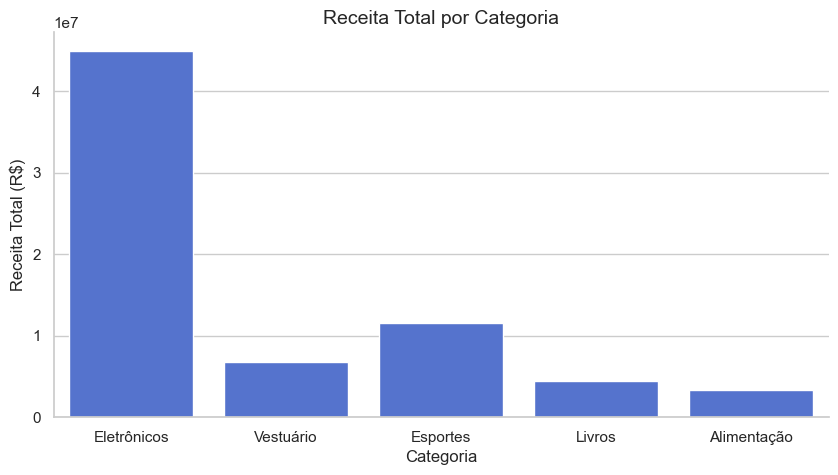

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

#Estilo base do Seaborn
sns.set_theme(style="whitegrid")

#A. Grafico de Barras: Receita Total por Categoria
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='categoria', y='receita_total', estimator=sum, errorbar=None, color='royalblue')
plt.title("Receita Total por Categoria", fontsize=14)
plt.xlabel("Categoria")
plt.ylabel("Receita Total (R$)")
sns.despine()
plt.show()

**Interpretação (Grafico de Barras):** Este grafico mostra a soma total da receita gerada por cada categoria. Fica visualmente claro qual segmento de produtos e o carro-chefe da empresa em termos de faturamento.

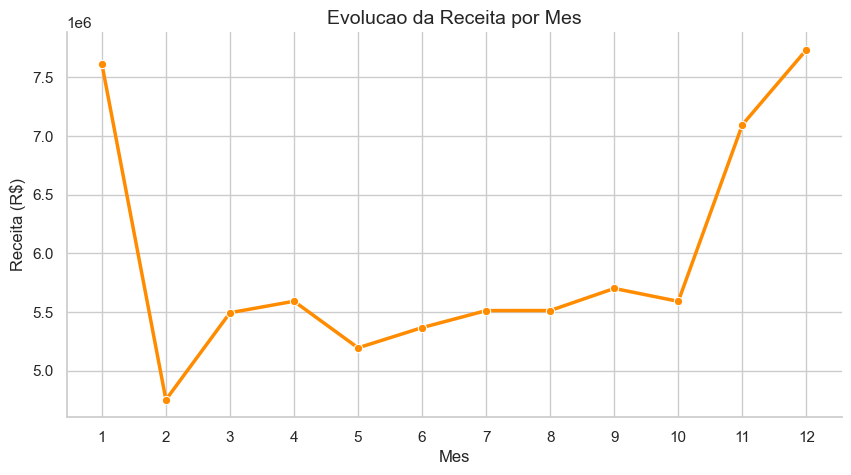

In [20]:
#B. Grafico de Linhas: Receita por Mes
plt.figure(figsize=(10, 5))
receita_por_mes = df.groupby('mes')['receita_total'].sum().reset_index()
sns.lineplot(data=receita_por_mes, x='mes', y='receita_total', marker="o", linewidth=2.5, color='darkorange')
plt.title("Evolucao da Receita por Mes", fontsize=14)
plt.xlabel("Mes")
plt.ylabel("Receita (R$)")
plt.xticks(range(1, 13)) #Garante que todos os 12 meses aparecam no eixo X
sns.despine()
plt.show()

**Interpretacao (Grafico de Linha):** O grafico revela a sazonalidade das vendas ao longo do ano, destacando os picos de faturamento e os meses de baixa, o que ajuda no planejamento do estoque.

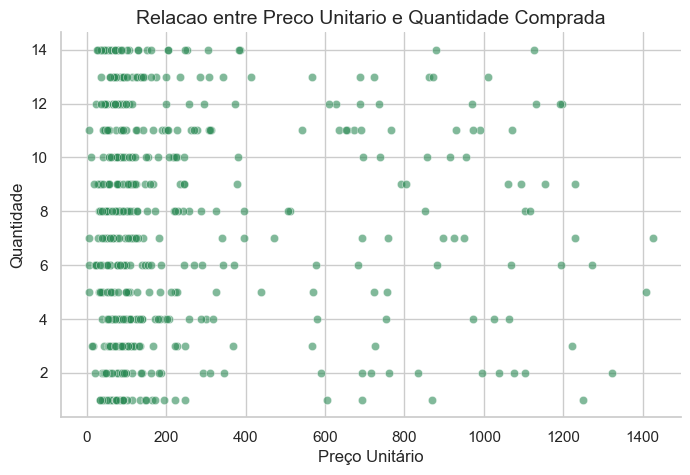

In [21]:
#C. Grafico de Dispersao: Preco Unitario e Quantidade (Amostra de 500 para nao poluir)
plt.figure(figsize=(8, 5))
amostra = df.sample(n=min(500, len(df)), random_state=42)
sns.scatterplot(data=amostra, x='preco_unitario', y='quantidade', alpha=0.6, color='seagreen')
plt.title("Relacao entre Preco Unitario e Quantidade Comprada", fontsize=14)
plt.xlabel("Preço Unitário")
plt.ylabel("Quantidade")
sns.despine()
plt.show()

**Interpretação (Grafico de Dispersao):** Analisando a amostra, podemos verificar a relacao entre o preco de um item e a quantidade que o cliente costuma levar. Geralmente, itens mais baratos tendem a ser comprados em maior volume.

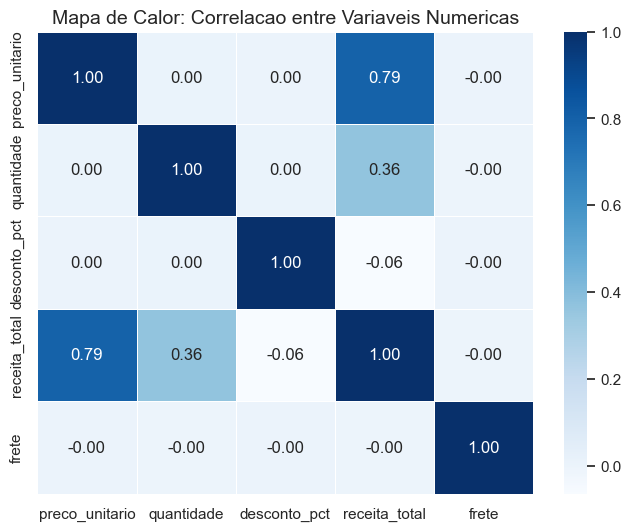

In [22]:
#D. Mapa de Calor (Heatmap): Correlacoes
plt.figure(figsize=(8, 6))

#Selecionando apenas algumas colunas numericas
colunas_num = df[['preco_unitario', 'quantidade', 'desconto_pct', 'receita_total', 'frete']]
correlacao = colunas_num.corr()

sns.heatmap(correlacao, annot=True, cmap="Blues", fmt=".2f", linewidths=.5)
plt.title("Mapa de Calor: Correlacao entre Variaveis Numericas", fontsize=14)
plt.show()

**Interpretacao (Mapa de Calor):** O heatmap mostra como as variaveis se relacionam. Correlacoes proximas de 1 indicam forte relacao positiva (ex: quanto maior o preco, maior a receita, dependendo do item). Ajuda a encontrar padroes escondidos entre os valores.

**Conclusao Final:** A juncao de NumPy, Pandas e Seaborn permitiu sair de dados puros (e alguns ate sujos/nulos) para paineis claros de gestao. Identificamos os produtos que mais faturam, meses sazonais e o comportamento de preço versus quantidade, respondendo as duvidas essenciais do negocio.